In [ ]:
!pip install matplotlib numpy scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [1]:
%load_ext autoreload
%autoreload 2

from scipy.constants import speed_of_light as SPEED_OF_LIGHT
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from copy import copy
import sys
import os
import pickle

from simulation import *

# importlib.reload(simulation)

np.set_printoptions(threshold=sys.maxsize)

In [ ]:
base_seed = 1234
batches = 10
realizations = 100

bs_setup = "mmWave"
scenarios = list(SCENARIOS[bs_setup].keys())

dl_prbs = SCENARIOS[bs_setup][scenarios[0]]["N_PRBS"] - SCENARIOS[bs_setup][scenarios[0]]["UPLINK_PRBS"]
sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
sensor_densities = SCENARIOS[bs_setup][scenarios[0]]["SENSOR_DENSITIES"]

In [ ]:
metric_values = {
    metric: {
        (s, d): np.array([]).reshape(0, len(sensing_portions))
        for s in scenarios
        for d in sensor_densities
    }
    for metric in [
        "mean_ue_comm_thr",
    ]
}

raw_ue_values = {
    metric: {
        (s, d): np.array([])
        for s in scenarios
        for d in sensor_densities
    }
    for metric in [
        "ue_peak_thr_alloc_decision",
    ]
}

for b in range(batches):
    np.random.seed(base_seed + b)

    for s in scenarios:
        data = copy(SCENARIOS[bs_setup][s])
        data["REALIZATIONS"] = realizations
        data = pos_vehicles(data, no_warning=True)
        for d in sensor_densities:
            data["SENSOR_DENSITY"] = d
            dl_prbs = data["N_PRBS"] - data["UPLINK_PRBS"]
            sensing_portions = np.arange(0, dl_prbs+1)/dl_prbs
            
            data = pos_sensors(data, no_warning=True)
            data = run_pre_allocation_and_assignment(data)
            data = run_angle_interference_derivations(data)
            data = alloc_beams(data)
            data = run_beam_allocation_interference_derivations(data)
            data = alloc_bandwidth(data, method="orthogonal_split_equal", sens_portions=sensing_portions)
            data = run_pre_assignment(data)
            data = assign_sensors(data)
            data = run_post_assignment(data)

            for metric in raw_ue_values.keys():
                if len(data[metric].shape) == 2: # [realization, vehicle]
                    raw_ue_values[metric][s,d] = np.append(raw_ue_values[metric][s,d], data[metric][data["ue_mask"]])
                elif len(data[metric].shape) == 3: # [realization, vehicle, alloc_decision]
                    # Apply the peak throughput allocation decision
                    realization_indices = np.arange(data[metric].shape[0])[:, np.newaxis]
                    vehicle_indices = np.arange(data[metric].shape[1])[np.newaxis, :]
                    idx = (realization_indices, vehicle_indices, data["ue_peak_thr_alloc_decision"])
                    values = data[metric][idx][data["ue_mask"]]
                    raw_ue_values[metric][s,d] = np.append(raw_ue_values[metric][s,d], values)
                else:
                    raise ValueError(f"Unexpected shape for metric {metric}: {data[metric].shape}")

            for metric in metric_values.keys():
                values = data[metric]
                if len(values.shape) == 2: # [realization, alloc_decision]
                    mean_value_per_alloc_decision = np.mean(values, axis= 0) # [alloc_decision]
                elif len(values.shape) == 3: # [realization, vehicle, alloc_decision]
                    mean_value_per_alloc_decision = np.mean( # [alloc_decision]
                        values, # [realization, vehicle, alloc_decision]
                        axis=(0,1), # Average over realizations and vehicles if alloc_decision is present, otherwise just realizations
                        where=data["ue_mask"][..., np.newaxis] # [realization, vehicle, alloc_decision]
                    )
                metric_values[metric][s,d] = np.vstack([metric_values[metric][s,d], mean_value_per_alloc_decision[np.newaxis, :]]) # [batch, alloc_decision]

for s in scenarios:
    for d in sensor_densities:
        for metric in metric_values.keys():
            metric_values[metric][s,d] = np.mean(metric_values[metric][s,d], axis=0) # [alloc_decision]


In [4]:
print("Best and worst cases for angle error:\n")

print(
    f"At min main lobe beamwidth ({np.rad2deg(data['min_half_beamwidth']):.2f}°):" +
    f" {np.tan(data['min_half_beamwidth']) * 10:.2f} m (UE at 10 m from the BS)"+
    f" {np.tan(data['min_half_beamwidth']) * data['CELL_RANGE']:.2f}m (UE at the cell edge)"
)

print(
    f"At max main lobe beamwidth ({np.rad2deg(data['max_half_beamwidth']):.2f}°):" +
    f" {np.tan(data['max_half_beamwidth']) * 10:.2f} m (UE at 10 m from the BS)"+
    f" {np.tan(data['max_half_beamwidth']) * data['CELL_RANGE']:.2f} m (UE at the cell edge)"
)

Best and worst cases for angle error:

At min main lobe beamwidth (6.11°): 1.07 m (UE at 10 m from the BS) 42.80m (UE at the cell edge)
At max main lobe beamwidth (8.46°): 1.49 m (UE at 10 m from the BS) 59.51 m (UE at the cell edge)


In [5]:
# Save metric_values
os.makedirs("results", exist_ok=True)
with open("results/2_communication_performance_metric_values.pkl", "wb") as f:
    pickle.dump(metric_values, f)
with open("results/2_communication_performance_raw_ue_values.pkl", "wb") as f:
    pickle.dump(raw_ue_values, f)

In [6]:
# Read metric_values
with open("results/2_communication_performance_metric_values.pkl", "rb") as f:
    metric_values = pickle.load(f)
with open("results/2_communication_performance_raw_ue_values.pkl", "rb") as f:
    raw_ue_values = pickle.load(f)

In [7]:
scenario_labels = {
    (s, d): f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U {SCENARIOS[bs_setup][s]['TARGET_DENSITY']*1e6:.0f}T {d*1e6:.0f}S / km²"
    for s in scenarios
    for d in sensor_densities
}

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 8,

    # IEEE-like sizing
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [8]:
all_peak_thr_sens_portions = np.array([])
for s in scenarios:
    for d in sensor_densities:
        peak_thr_sens_portions = sensing_portions[raw_ue_values["ue_peak_thr_alloc_decision"][s, d].astype(int)]
        std_dev_portions = np.std(peak_thr_sens_portions)
        sorted_portions = np.sort(peak_thr_sens_portions)
        cdf_x = np.linspace(0, 1, len(sorted_portions), endpoint=True)
        all_peak_thr_sens_portions = np.append(all_peak_thr_sens_portions, peak_thr_sens_portions)
        thr_req = SCENARIOS[bs_setup][s]["REQ_THROUGHPUT"]
        range_sens_portions_above_req = sensing_portions[np.where(metric_values['mean_ue_comm_thr'][s, d] >= thr_req)[0]]
        max_sens_portion_above_req = np.max(range_sens_portions_above_req) if len(range_sens_portions_above_req) > 0 else 0
        min_sens_portion_above_req = np.min(range_sens_portions_above_req) if len(range_sens_portions_above_req) > 0 else 0

        print("Scenario:", scenario_labels[(s, d)])
        print(f"Average Throughput: {np.mean(metric_values['mean_ue_comm_thr'][s, d]/1e6):.2f}Mbps")
        print(f"Peak Throughput: {np.max(metric_values['mean_ue_comm_thr'][s, d]/1e6):.2f}Mbps")
        print(f"Mean Peak Throughput Sensing Portion: {np.mean(peak_thr_sens_portions)*100:.1f}%")
        print(f"Std Dev Peak Throughput Sensing Portion: {std_dev_portions*100:.1f}%")
        print(f"Min Peak Throughput Sensing Portion: {np.min(peak_thr_sens_portions)*100:.1f}%")
        print(f"Max Peak Throughput Sensing Portion: {np.max(peak_thr_sens_portions)*100:.1f}%")
        print(f"Range of Sensing Portions with Mean Throughput Above the Required: {min_sens_portion_above_req*100:.1f}% - {max_sens_portion_above_req*100:.1f}%")
        idx_highest_mean_thr = np.mod(np.argmax(metric_values['mean_ue_comm_thr'][s, d]), realizations)
        print(f"Sensing Portion at Highest Mean Throughput: {sensing_portions[idx_highest_mean_thr]*100:.1f}%")
        print("")

print(f"Mean Peak Throughput Sensing Portion Across All Scenarios: {np.mean(all_peak_thr_sens_portions)*100:.1f}%")
print(f"Std Dev of Peak Throughput Sensing Portion Across All Scenarios: {np.std(all_peak_thr_sens_portions)*100:.1f}%")

peak_thr_idx_per_scenario = np.mod([np.argmax(metric_values['mean_ue_comm_thr'][s, d]) for s in scenarios for d in sensor_densities], realizations)
avg_sens_portion_at_peak_thr = np.mean([sensing_portions[idx] for idx in peak_thr_idx_per_scenario])
print(f"Mean Sensing Portion at Highest Mean Throughput Across All Scenarios: {avg_sens_portion_at_peak_thr*100:.1f}%")



Scenario: 50U 150T 5S / km²
Average Throughput: 85.50Mbps
Peak Throughput: 155.19Mbps
Mean Peak Throughput Sensing Portion: 4.8%
Std Dev Peak Throughput Sensing Portion: 2.0%
Min Peak Throughput Sensing Portion: 0.0%
Max Peak Throughput Sensing Portion: 9.8%
Range of Sensing Portions with Mean Throughput Above the Required: 0.0% - 87.8%
Sensing Portion at Highest Mean Throughput: 4.9%

Scenario: 50U 150T 15S / km²
Average Throughput: 85.22Mbps
Peak Throughput: 154.72Mbps
Mean Peak Throughput Sensing Portion: 4.8%
Std Dev Peak Throughput Sensing Portion: 2.0%
Min Peak Throughput Sensing Portion: 2.4%
Max Peak Throughput Sensing Portion: 7.3%
Range of Sensing Portions with Mean Throughput Above the Required: 0.0% - 87.8%
Sensing Portion at Highest Mean Throughput: 4.9%

Scenario: 50U 300T 5S / km²
Average Throughput: 50.71Mbps
Peak Throughput: 93.23Mbps
Mean Peak Throughput Sensing Portion: 4.9%
Std Dev Peak Throughput Sensing Portion: 2.1%
Min Peak Throughput Sensing Portion: 0.0%
Max P

<>:118: SyntaxWarning: invalid escape sequence '\%'
<>:118: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_244915/1283089603.py:118: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Normalized Sensing Bandwidth (\%)")


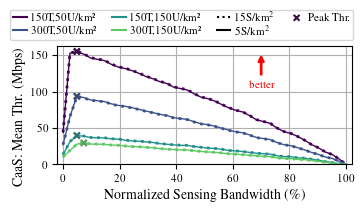

In [9]:
scenario_labels = {
    (s, d): f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U {SCENARIOS[bs_setup][s]['TARGET_DENSITY']*1e6:.0f}T {d*1e6:.0f}S / km²"
    for s in scenarios
    for d in sensor_densities
}

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,

    # IEEE-like sizing
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Better PDF output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


colors = plt.cm.viridis(np.linspace(0, 1, len(scenarios), endpoint=False))
color_dict = {s: colors[idx] for idx, s in enumerate(scenarios)}

scenario_label_no_density = {
    s: (f"{(SCENARIOS[bs_setup][s]['TARGET_DENSITY'])*1e6:.0f}T,"
        + f"{SCENARIOS[bs_setup][s]['UE_DENSITY']*1e6:.0f}U/km²"
    )
    for s in scenarios
}




default_density = sensor_densities[0]

plt.rcParams.update({'font.size': 12})

mean_sens_port_at_peak_ue_thr = np.mean([
    np.mean(
        sensing_portions[
            raw_ue_values["ue_peak_thr_alloc_decision"][s].astype(int)
        ]
    )
    for s in scenario_labels
])


# =========================================================
# Figure
# =========================================================
fig, ax = plt.subplots(
    figsize=(3.5, 2),
    constrained_layout=True
)

# =========================================================
# Throughput vs sensing portion
# =========================================================
for idx, s in enumerate(scenario_labels):

    values = np.array(metric_values["mean_ue_comm_thr"][s]) / 1e6

    ax.plot(
        sensing_portions * 100,
        values,
        label=scenario_label_no_density[s[0]] if s[1] != default_density else None,
        color=color_dict[s[0]],
        lw=1 if s[1] != default_density else 2,
        linestyle="-" if s[1] != default_density else ":"
    )

# =========================================================
# Peak Scatters
# =========================================================

peak_sens_ports_idxs = [
    np.argmax(metric_values['mean_ue_comm_thr'][s])
    for s in scenario_labels
]
peak_thr = [
    np.max(metric_values['mean_ue_comm_thr'][s])/1e6
    for s in scenario_labels
]


scatter_colors = []
for c in colors:
    hsv = rgb_to_hsv(c[:3])  # ignore alpha
    hsv[1] *= 0.8 # change saturation
    hsv[2] *= 0.8 # change brightness
    rgb = hsv_to_rgb(hsv)
    scatter_colors.append(np.append(rgb, c[3]))  # restore alpha
scatter_colors = np.array(scatter_colors)
scatter_colors = np.repeat(scatter_colors, 2, axis=0) # repeat for both densities

ax.scatter(
    x=sensing_portions[peak_sens_ports_idxs] * 100,
    y=peak_thr,
    color=scatter_colors,
    marker="x",
    s=18,
    zorder=10,
    label="Peak Thr.",
)


REQ_THROUGHPUT_mbps = (
    SCENARIOS[bs_setup][scenarios[0]]["REQ_THROUGHPUT"] / 1e6
)

ax.set_ylim(0, None)
ax.set_xlim(-2, 102)
ax.set_xticks(np.linspace(0, 100, 6, endpoint=True))
ax.set_xlabel("Normalized Sensing Bandwidth (\%)")
ax.set_ylabel("CaaS: Mean Thr. (Mbps)")
ax.grid()

handles, labels = ax.get_legend_handles_labels()

# Existing scenario handles (remove SLA/SPMMT if desired)
old_handles = handles[:-2]
old_labels = labels[:-2]

old_handles = [
    Line2D(
        [0], [0],
        color=color_dict[s],
        lw=1.5,
    )
    for s in scenarios
]

old_labels = [
    scenario_label_no_density[s] if s[1] != default_density else None
    for s in scenarios
]

# Sensor density handles
sensor_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        label=f"{sensor_densities[1]*1e6:.0f} sensors/km$^2$"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        label=f"{default_density*1e6:.0f} sensors/km$^2$"
    ),
]

sensor_labels = [
    f"{sensor_densities[1]*1e6:.0f}S/km$^2$",
    f"{default_density*1e6:.0f}S/km$^2$",
]

handles = old_handles + sensor_handles + handles[-1:]
labels = old_labels + sensor_labels + labels[-1:]

ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(-0.18, 1.35, 1.205, 0),
    mode="expand",
    ncol=4,
    labelspacing=0.3,
    borderpad=0.3,
    handlelength=1.2,
    handletextpad=0.4,
)
ax.yaxis.set_label_coords(-0.11, 0.40)

ax.annotate(
    "better",
    xy=(70, ax.get_ylim()[1] * 0.95),      # arrow tip (top)
    xytext=(70, ax.get_ylim()[1] * 0.67),  # text below
    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        color="red",
    ),
    ha="center",
    va="center",
    fontsize=8,
    color="red"
)

os.makedirs("figures", exist_ok=True)

fig.savefig(
    "figures/2_communication_performance.pdf",
    bbox_inches="tight"
)

plt.show()